<a href="https://colab.research.google.com/github/mariacgomez-tech/Analitica-de-Negocios/blob/main/Diabetes1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de Estudio**
En este documento se desarrolla un análisis de clasificación de pacientes con y sin diabetes utilizando variables relacionadas con su estado de salud. Para ello se emplea la base de datos Pima Indians Diabetes Database, la cual contiene información clínica y demográfica de pacientes junto con una variable objetivo llamada Outcome, que indica si el paciente presenta diabetes (1) o no presenta diabetes (0).

Con el objetivo de analizar el comportamiento de estas variables frente a la enfermedad, se aplican tres modelos de analítica de datos: **Naive Bayes, Árbol de Decisión y Clustering K-Means**, permitiendo comparar su desempeño en la clasificación y segmentación de pacientes.

El análisis incluye un análisis exploratorio de datos, un análisis de correlación entre variables, la evaluación del desempeño de los modelos mediante la matriz de confusión y métricas derivadas, y finalmente la clasificación de un paciente específico definido por el vector:

**XDp = [2, 85, 65, 29, 94, 39.6, 0.93, 27]**.

Finalmente, se analizará el comportamiento de los tres modelos frente al paciente:

De acuerdo con lo anterior, las variables utilizadas en el análisis son:

- **Pregnancies**: número total de embarazos que ha tenido la paciente.
- **Glucose**: concentración de glucosa en plasma, una de las variables clínicas más importantes para el diagnóstico de diabetes.
- **BloodPressure**: presión arterial diastólica medida en (mm Hg).
- **SkinThickness**: grosor del pliegue cutáneo del tríceps, utilizado como indicador de grasa corporal.
- **Insulin**: nivel de insulina sérica, relacionado con la regulación de glucosa en sangre.
- **BMI**: índice de masa corporal.
- **DiabetesPedigreeFunction**: indicador de predisposición genética a diabetes.
- **Age**: edad del paciente.

0. Se procede con la carga de librerías de trabajo.

In [ ]:
import numpy as np #Librería numérica por excelencia.
import pandas as pd #Librería para la comunicación con archivos de excel

#Librerías modelo Naive Bayes
#Librerías específicas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

#Librerías modelo Árbol de decisión
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

#Librerías modelo Clustering K-means
import matplotlib.pyplot as plt
import seaborn as sns #Herramientas para gráficas estadisticas
from sklearn.cluster import KMeans #Herramienta de clustering

**Naive Bayes**

1. Se cargan datos de trabajo.

In [ ]:
nxl='/content/Base de datos reto 1.xlsx' #Las hojas de excel se empiezan a contar desde 0
XDB=pd.read_excel(nxl,sheet_name=0)
#XDB.head(100) #Es para mostrar la base de datos cargada (el numero que esta entre parentesis es el número de filas que muestra)

#Seleccionamos variables de trabajo
XD=XDB[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']] #Variables de trabajo
XD.head(10)
yd=XDB[['Outcome']] #Variable de decisión
yd.head()


,Outcome
0,1
1,0
2,1
3,0
4,1


3. Implementamos modelo Naive Bayes

In [ ]:
mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar variables Entrada - Salida

#Mostramos las medias de las variables
u=mnb.theta_
sigma=mnb.var_; sigma=np.sqrt(sigma) #Varianza es sigma al cuadrado. La desviación es la raiz cuadrada de sigma
print("'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'")
print(u)
print("Las desviaciones son:")
print(sigma)
print("El limite superior de las variables es:")
print(u+sigma)
print("El limite inferior de las variables es:")
print(u-sigma)

'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
Las desviaciones son:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]
El limite superior de las variables es:
[[  6.31216809 136.09504573  86.22900366  34.53905016 167.55837459
   37.98636217   0.72854226  42.84598187]
 [  8.59992601 173.13744041  92.27630469  39.81087552 238.76595549
   42.39194249   0.92217699  48.01493615]]
El limite inferior de las variables es:
[[  0.28383191  83.86495427  50.13899634   4.78894984 -29.97437459
   22.62203783   0.13092574  19.53401813]
 [  1.13141727 109.3774849

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Análisis de resultados**

De acuerdo con los resultados obtenidos en el modelo Naive Bayes, se observa que existen diferencias claras entre las variables promedio de los pacientes clasificados como **Diabetes** y **No Diabetes**. En particular, la variable **Glucose** presenta valores promedio significativamente mayores en la categoría de pacientes con diabetes en comparación con los pacientes sin diabetes, lo que indica que el nivel de glucosa en sangre es una de las variables más influyentes en la identificación de esta enfermedad.

De igual manera, el **BMI (Índice de Masa Corporal)** presenta valores promedio más altos en los pacientes con diabetes, lo cual sugiere que el sobrepeso y la obesidad están asociados con una mayor probabilidad de desarrollar la enfermedad. Esta relación es consistente con el conocimiento médico, donde un mayor índice de masa corporal suele estar relacionado con mayores riesgos metabólicos.

También se observa que la **edad promedio** de los pacientes con diabetes es mayor que la de los pacientes sin diabetes, lo que indica que el riesgo de padecer esta enfermedad aumenta con el paso del tiempo. De forma similar, la variable **Pregnancies** muestra valores promedio mayores en el grupo de pacientes con diabetes, lo que puede estar asociado con factores hormonales o metabólicos que influyen en la aparición de la enfermedad.

En general, los resultados del modelo muestran que variables como **Glucose, BMI, Age y Pregnancies** presentan diferencias importantes entre las dos categorías, lo que indica que estas variables tienen un papel relevante en la clasificación de pacientes con y sin diabetes dentro del modelo Naive Bayes.

4. Se procede con la evaluación del modelo. Para la evaluación de este tipo de modelo se utiliza la matriz de confusión.

**Desempeño del modelo**

In [ ]:
ydp=mnb.predict(XD) #Esto es lo que el modelo aprende - ydp de pronóstico
cm=confusion_matrix(yd,ydp)
print(cm)
#Revisar diagonal principal. La suma de las filas es el total de datos (1 son preAprobados, 0 PreNegados)
#Se determinan las métricas de la matriz de confusión
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)
#1. Exactitud: Funcionamiento general del modelo (Primera métrica, como funcionó pronosticando)
Ex=(VP+VN)/(TDatos)
print("Exactitud: ",Ex)
#2. Tasa de error: % fallos del sistema
TEr=(FP+FN)/(TDatos)
print("Tasa de error: ",TEr) #Modelo que pase del 75% es muy bueno
#3. Sensibilidad: Como se  comportó con respecto a los positivos. (fila)
Se=VP/(VP+FN)
print("Sensibilidad: ",Se)
#4. Especificidad: Como se comporta pronosticando negativos
Es=VN/(VN+FP)
print("Especificidad: ",Es)
#5. Precisión: Es una versión de como se comporta el modelo frente a los positivos solamente. (columna)
Pr=VP/(VP+FP)
print("Precisión: ",Pr)
#6. Predicción Negativa: como funciona el modelo pronosticando créditos PreNegados
PrN=VN/(VN+FN)
print("Predicción Negativa: ",PrN)

[[421  79]
 [103 165]]
Exactitud:  0.7630208333333334
Tasa de error:  0.23697916666666666
Sensibilidad:  0.6156716417910447
Especificidad:  0.842
Precisión:  0.6762295081967213
Predicción Negativa:  0.8034351145038168


**Análisis de resultados**

De acuerdo con los resultados obtenidos, se puede observar que el modelo Naive Bayes alcanzó una **exactitud cercana al 76.3%**, lo que indica un buen comportamiento general del modelo frente a la clasificación de pacientes con diabetes y sin diabetes. Esto significa que el modelo logra clasificar correctamente aproximadamente tres de cada cuatro pacientes de la base de datos.

Se destaca particularmente la **especificidad del modelo, con un valor de 84.2%**, lo que indica que el modelo tiene un muy buen desempeño al identificar correctamente a los pacientes que **no presentan diabetes**. Este resultado muestra que el modelo es bastante confiable cuando predice casos negativos.

Por otro lado, la **precisión del modelo es de aproximadamente 67.6%**, lo que indica que una proporción importante de los pacientes clasificados como diabéticos realmente pertenecen a esta categoría, aunque todavía existen algunos errores de clasificación.

En cuanto a la **sensibilidad del modelo (61.6%)**, se observa que el modelo tiene una capacidad moderada para identificar correctamente a los pacientes que realmente presentan diabetes. Esto significa que algunos pacientes positivos no son detectados por el modelo, lo cual afecta la exactitud general del sistema.

La **predicción negativa del modelo (80.3%)** muestra que cuando el modelo clasifica a un paciente como no diabético, existe una alta probabilidad de que dicha clasificación sea correcta.

En general, el modelo presenta un desempeño adecuado para la clasificación de pacientes, especialmente en la identificación de pacientes sin diabetes. Sin embargo, la exactitud se ve ligeramente afectada por los errores en la clasificación de pacientes con diabetes, lo cual se refleja principalmente en los valores de sensibilidad del modelo.

4. Análisis paciente XDp=[2,85,65,29,94,39.6,0.93,27] en el modelo Naive Bayes

In [ ]:
XP=[2,85,65,29,94,39.6,0.93,27]
ydc=mnb.predict([XP])
print(ydc)

if ydc==1:
  print("El solicitante tiene Diabetes")
else:
  print("El solicitante no tiene Diabetes")

[0]
El solicitante no tiene Diabetes


**Árbol de decisión**

1. Se cargan datos de trabajo

In [ ]:
nxl='/content/Base de datos reto 1.xlsx' #Las hojas de excel se empiezan a contar desde 0
XDB=pd.read_excel(nxl,sheet_name=0)

XD2=XDB.iloc[:, [0,1,2,3,4,5,6,7]]
yd2=XDB.iloc[:, 8]
display(XD2)
display(yd2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


2. Se procede con la implementación del modelo de árbol.

In [ ]:
mar=DecisionTreeClassifier(criterion='gini', max_depth=4)
mar.fit(XD2,yd2) #Aquí se ajusta el modelo. Busca relación entrada-salida

# Y qué fue lo que hizo el modelo?
ydp=mar.predict(XD2) #Esto es lo que pronostica el modelo

#Se construye la matriz de confusión
cm=confusion_matrix(yd2,ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

#Métricas de desempeño
Ex=(VP+VN)/len(XD2) #1. Exactitud: Comportamiento general
print('La Exactitud es: ',Ex)
Sen=VP/(VP+FN) #2. Sensibilidad: Como se comporta pronosticando PreAprobados
print('La Sensibilidad es: ',Sen)
Spe=VN/(VN+FP) #3. Especificidad: Como se comporta frente a los negativos
print('La Especificidad es: ',Spe)
Pre=VP/(VP+FP) #4. Precisión: Como se comporta pronosticando PreAprobados
print('La Precisión es: ',Pre)
PreNeg=VN/(VN+FN) #5. Precisión Negativa: Como se comporta pronosticando Negativos
print('La Precisión Negativa es: ',PreNeg)

array([[459,  41],
       [119, 149]])

La Exactitud es:  0.7916666666666666
La Sensibilidad es:  0.5559701492537313
La Especificidad es:  0.918
La Precisión es:  0.7842105263157895
La Precisión Negativa es:  0.7941176470588235


3. Despliegue de árbol

In [ ]:
from sklearn.tree import export_graphviz #Exporta los datos a un gráfico
from pydotplus import graph_from_dot_data #Es un graficador
np.random.seed(42)

vs=["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"] #Títulos del árbol
dot_data=export_graphviz(mar, feature_names=vs) #Exportar de números a gráfico en pdf
graph=graph_from_dot_data(dot_data) #Graficamo el árbol
graph.write_png('arbolDiabetes.png') #Guardamos el árbol en pdf

True

4. Análisis paciente XDp=[2,85,65,29,94,39.6,0.93,27] en el modelo árbol de decisión

In [ ]:
XP=[2,85,65,29,94,39.6,0.93,27]
ydc=mnb.predict([XP])
print(ydc)

if ydc==1:
  print("El solicitante tiene Diabetes")
else:
  print("El solicitante no tiene Diabetes")

[0]
El solicitante no tiene Diabetes


**Análisis de resultados**

De acuerdo con el árbol de decisión obtenido, se puede observar que la base de datos contiene un total de **768 pacientes**, de los cuales **500 pertenecen a la categoría No Diabetes**, mientras que **268 pacientes pertenecen a la categoría Diabetes**. Esto indica que la base de datos presenta una mayor proporción de pacientes sin diabetes.

El árbol de decisión identifica como variable principal de clasificación el **nivel de glucosa (Glucose)**, ya que esta variable aparece en el nodo raíz del modelo con un punto de corte de **127.5**. Esto indica que el nivel de glucosa es el factor más importante para diferenciar entre pacientes con diabetes y sin diabetes dentro del conjunto de datos.

Cuando los valores de **Glucose son menores o iguales a 127.5**, el modelo continúa la clasificación utilizando variables como **Age y BMI**, lo que indica que en pacientes con niveles moderados de glucosa la edad y el índice de masa corporal juegan un papel importante para determinar la probabilidad de diabetes. Por otro lado, cuando los valores de **Glucose son mayores a 127.5**, el modelo utiliza principalmente variables como **BMI, Age e Insulin** para realizar nuevas divisiones, lo que sugiere que en pacientes con niveles altos de glucosa estas variables ayudan a identificar el riesgo de la enfermedad.

De acuerdo con el árbol de decisión se destacan varios **nodos puros**, es decir, nodos donde el modelo clasifica todos los casos en una misma categoría (gini = 0). Por ejemplo, se observa un nodo puro con **39 pacientes clasificados como No Diabetes (39/0)**, lo que indica que bajo ciertas condiciones de las variables el modelo puede identificar completamente a los pacientes sin diabetes.

También se observa un nodo puro con **13 pacientes clasificados como Diabetes (0/13)**, lo que indica que bajo determinadas combinaciones de variables el modelo logra identificar completamente a los pacientes con diabetes.

Estos nodos puros representan reglas claras de clasificación dentro del modelo. Por ejemplo, una de las reglas identificadas indica que cuando se cumplen ciertas condiciones relacionadas con **Glucose, Age y BMI**, el modelo clasifica al paciente completamente dentro de una sola categoría.

Aunque no todos los nodos del árbol son completamente puros, también se observan **nodos extremos** donde el porcentaje de una de las categorías es muy alto. Esto indica que el modelo logra diferenciar adecuadamente entre pacientes con y sin diabetes en diferentes regiones del espacio de variables.

En general, el árbol de decisión permite identificar reglas claras basadas principalmente en **Glucose, BMI, Age e Insulin**, lo que demuestra que estas variables tienen una influencia significativa en la clasificación de pacientes con diabetes dentro del conjunto de datos analizado.


**Clustering K-Means**

1. Se cargan datos de trabajo

<Axes: >

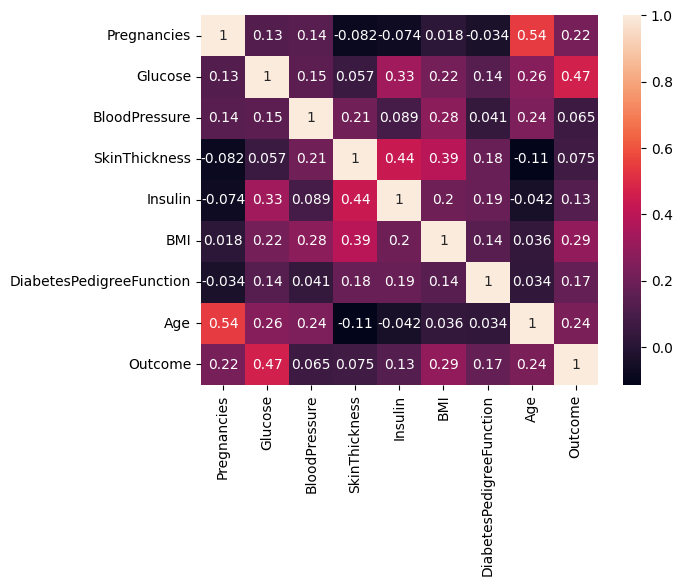

In [ ]:
nxl='/content/Base de datos reto 1.xlsx' #Las hojas de excel se empiezan a contar desde 0
XDB=pd.read_excel(nxl,sheet_name=0)

XD2=XDB.iloc[:, [0,1,2,3,4,5,6,7]]
yd2=XDB.iloc[:, 8]

#Determinemos la correlación entre las variables
XDB2=XDB.iloc[:, [0,1,2,3,4,5,6,7]]
sns.heatmap(XDB.corr(), annot=True)

2. Implementamos modelo Clustering K-Means

In [ ]:
np.random.seed(42) #Esto permite generar las mismas semillas para todos
NC=5 #Segmentos o perfiles de cliente
mkm=KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD2, yd2) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_ que encontró el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_, columns=XD2.columns)
display(Tabla)

#Para saber los porcentajes de PreApr o PreNeg por segmento, sucursal, o perfil
ydp2=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp2) #Esto me indica cuantos datos hay en cada cluster (#datos por segmento)
print('El número de datos por cluster es: ', NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El número de datos por cluster es:  [ 52 384 177  18 137]


3. Porcentaje de pacientes con riesgo de diabetes

In [ ]:
df_clustered = XDB.copy()
df_clustered['Cluster'] = ydp2 # Use ydp2, which are the cluster labels from mkm.labels_

display(df_clustered)

# Determinar el número por Cluster
NApr = df_clustered.groupby('Cluster').agg({'Outcome': lambda x: (x==1).sum()})
NPrn = df_clustered.groupby('Cluster').agg({'Outcome': lambda x: (x==0).sum()})

# Para que la decición sea en porcentaje
NApr2 = NApr / (NApr + NPrn)
NPrn2 = NPrn / (NApr + NPrn)
df2 = pd.DataFrame(np.column_stack((NApr2, NPrn2)), columns=['Diabetes_Porcentaje','No_Diabetes_Porcentaje'])
display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,Diabetes_Porcentaje,No_Diabetes_Porcentaje
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


4. Análisis paciente XDp=[2,85,65,29,94,39.6,0.93,27] en el modelo Clustering K-Means

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

nueva_persona=np.array([[2,85,65,29,94,39.6,0.93,27]])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape: quitarle la estructura
NCl=ydp[0] #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster:", ydp)
print("El porcentaje de que tenga diabetes para la nueva persona es: ", NApr2.iloc[NCl])
print("El porcentaje de que no tenga diabetes para la nueva persona es: ", NPrn2.iloc[NCl])

La persona pertenece al cluster: [2]
El porcentaje de que tenga diabetes para la nueva persona es:  Outcome    0.129944
Name: 2, dtype: float64
El porcentaje de que no tenga diabetes para la nueva persona es:  Outcome    0.870056
Name: 2, dtype: float64


5. Se procede con la gráfica de clusters utilizando las variables más correlacionadas (Age, Pregnancies)

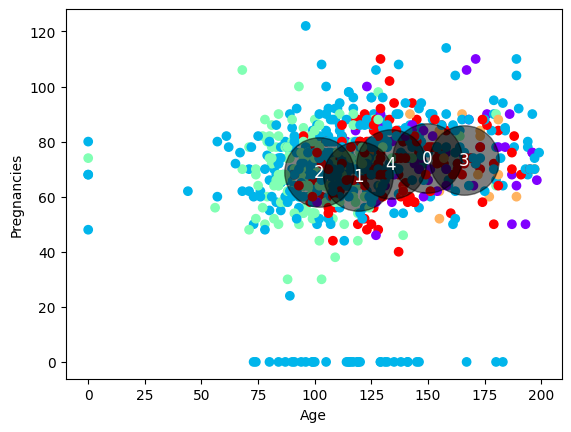

In [ ]:
centers=mkm.cluster_centers_ #Centroides, Perfil o segmento
ing=np.array(XD.iloc[:,1]); egr=np.array(XD.iloc[:,2]) #Ingresos y Egresos

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,1], centers[:,2], c='black', s=2500, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Pregnancies')

#Añade números a los circulos
for i, center in enumerate(centers):
    plt.text(center[1], center[2], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

**Análisis de resultados**

En el heatmap de correlación se puede observar que las variables con mayor relación entre sí son **Pregnancies y Age con una correlación de 0.54**, lo que indica que a mayor edad existe una mayor probabilidad de haber tenido más embarazos. También se destaca la correlación entre **Glucose y Outcome con un valor de 0.47**, lo que indica que el nivel de glucosa en sangre es una de las variables que mayor relación tiene con la presencia de diabetes en los pacientes.

Otra correlación relevante se observa entre **SkinThickness e Insulin (0.44)** y entre **SkinThickness y BMI (0.39)**, lo que sugiere que estas variables están relacionadas con características corporales asociadas al metabolismo y al riesgo de diabetes.

De acuerdo con los segmentos o clusters generados por el modelo K-Means, se identificaron **cinco grupos de pacientes con perfiles de salud diferentes**. Al analizar los centroides de cada cluster se observa que el **cluster 3 presenta los niveles promedio de glucosa más altos (165.83)** junto con un **BMI elevado (36.96)** y niveles altos de insulina, lo que indica que este grupo agrupa pacientes con un mayor riesgo metabólico.

Esto se confirma al analizar los porcentajes de diabetes por cluster, donde el **cluster 3 presenta la mayor probabilidad de diabetes con un 66.6%**, siendo el grupo con mayor proporción de pacientes diagnosticados con la enfermedad.

Por otro lado, el **cluster 2 presenta el menor porcentaje de diabetes con aproximadamente 12.99%**, lo que indica que este grupo agrupa principalmente pacientes con menor probabilidad de presentar la enfermedad. Este grupo presenta niveles más moderados de glucosa, BMI e insulina en comparación con los otros clusters.

Los **clusters 0 y 4 presentan porcentajes cercanos al 50%**, lo que indica que en estos grupos existe una distribución más equilibrada entre pacientes con y sin diabetes.

En general, el modelo de clustering permite identificar **diferentes perfiles de pacientes**, donde variables como **Glucose, BMI e Insulin** juegan un papel importante en la diferenciación de los grupos con mayor riesgo de diabetes.